# 02 — EDA & tokenization

Explores the cleaned splits, quantifies the class imbalance, compares the
two tokenizers, fixes `max_length`, and computes the class weights that
notebook 03 feeds into a weighted loss.

Covers assignment **steps 4a** (tokenization) and **4c** (imbalance).

Every figure is written to `results/figures/` — the report reads from there.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils  # noqa: E402

# Public models, so the token is optional — it only lifts the anonymous rate limit.
if os.environ.get("HF_TOKEN"):
    print("HF_TOKEN found in environment")

from transformers import AutoTokenizer  # noqa: E402

utils.ensure_dirs()
utils.set_seed()

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("colorblind", utils.NUM_LABELS)

splits = {
    name: pd.read_csv(utils.DATA_PROCESSED / f"{name}.csv")
    for name in ("train", "dev", "test")
}
train = splits["train"]
print({k: len(v) for k, v in splits.items()})
train.head(3)

{'train': 9989, 'dev': 1109, 'test': 2610}


,text,label,label_name,sentiment,speaker,dialogue_id
0,also I was the point person on my company's tr...,0,neutral,neutral,Chandler,0
1,You must've had your hands full.,0,neutral,neutral,The Interviewer,0
2,That I did. That I did.,0,neutral,neutral,Chandler,0


## 1. Class distribution — the imbalance story

This is the single most important property of MELD for modelling. Neutral is
roughly half of every split; fear and disgust sit under 3%. A model that
predicts "neutral" unconditionally already scores ~47% accuracy, which is why
accuracy alone is a misleading metric here and why macro F1 is reported
beside weighted F1.

In [2]:
dist = (
    pd.concat([df.assign(split=name) for name, df in splits.items()])
    .groupby(["split", "label_name"])
    .size()
    .rename("count")
    .reset_index()
)
dist["pct"] = dist.groupby("split")["count"].transform(lambda s: 100 * s / s.sum())

pivot = (
    dist.pivot(index="label_name", columns="split", values="pct")
    .loc[utils.LABEL_NAMES, ["train", "dev", "test"]]
    .round(2)
)
pivot

split,train,dev,test
label_name,,,
neutral,47.15,42.38,48.12
joy,17.45,14.70,15.40
surprise,12.06,13.53,10.77
anger,11.10,13.80,13.22
sadness,6.84,10.01,7.97
disgust,2.71,1.98,2.61
fear,2.68,3.61,1.92


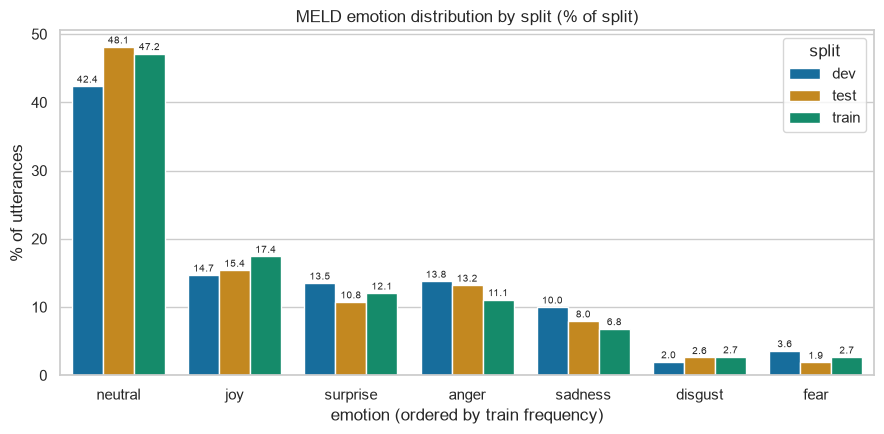

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = dist.copy()
plot_df["label_name"] = pd.Categorical(
    plot_df["label_name"], categories=utils.LABEL_NAMES, ordered=True
)
sns.barplot(
    data=plot_df, x="label_name", y="pct", hue="split", ax=ax, palette="colorblind"
)
ax.set_title("MELD emotion distribution by split (% of split)")
ax.set_xlabel("emotion (ordered by train frequency)")
ax.set_ylabel("% of utterances")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=7, padding=1)
fig.tight_layout()
fig.savefig(utils.FIGURES / "class_distribution.png", dpi=150)
plt.show()

In [4]:
counts = train["label_name"].value_counts()
imbalance_ratio = counts.max() / counts.min()
print(f"most frequent : {counts.idxmax():9s} {counts.max():5d}")
print(f"least frequent: {counts.idxmin():9s} {counts.min():5d}")
print(f"imbalance ratio: {imbalance_ratio:.1f}x")
print(f"majority-class baseline accuracy (train): {100 * counts.max() / len(train):.1f}%")

most frequent : neutral    4710
least frequent: fear        268
imbalance ratio: 17.6x
majority-class baseline accuracy (train): 47.2%


## 2. Utterance length

MELD lines are short — a median of 6 words. This is a substantive limitation,
not just a modelling convenience: many utterances carry no emotional signal
at all in isolation ("What?", "Hey."), and their gold label comes from
dialogue context and delivery that a text-only model never sees. Notebook 04
returns to this in the error analysis.

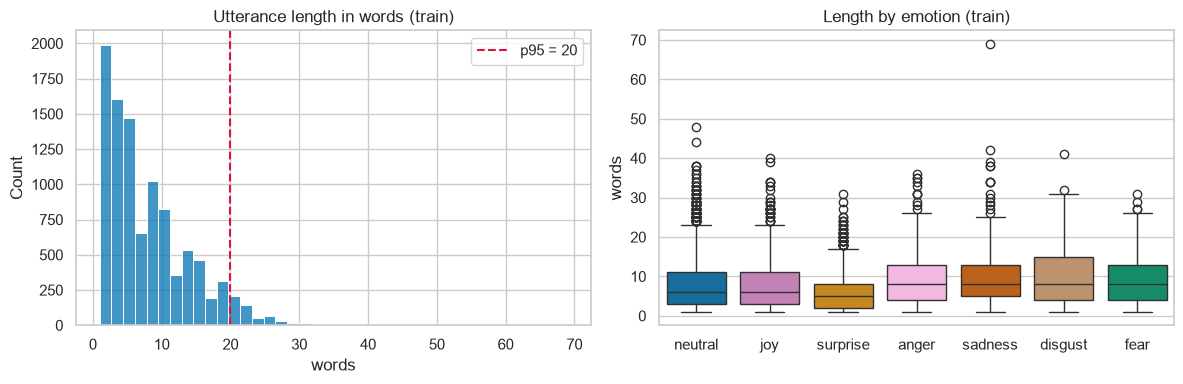

count    9989.00
mean        7.95
std         6.23
min         1.00
25%         3.00
50%         6.00
75%        11.00
max        69.00


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

words = train["text"].str.split().str.len()
sns.histplot(words, bins=40, ax=axes[0], color=PALETTE[0])
axes[0].axvline(words.quantile(0.95), color="crimson", ls="--", label=f"p95 = {int(words.quantile(0.95))}")
axes[0].set_title("Utterance length in words (train)")
axes[0].set_xlabel("words")
axes[0].legend()

order = utils.LABEL_NAMES
sns.boxplot(
    data=train.assign(n_words=words),
    x="label_name", y="n_words", order=order, ax=axes[1], palette="colorblind", hue="label_name", legend=False,
)
axes[1].set_title("Length by emotion (train)")
axes[1].set_xlabel("")
axes[1].set_ylabel("words")

fig.tight_layout()
fig.savefig(utils.FIGURES / "utterance_length.png", dpi=150)
plt.show()

print(words.describe().round(2).to_string())

## 3. Example utterances per class

A qualitative look at what each label actually contains.

In [6]:
examples = train.groupby("label_name").sample(3, random_state=utils.SEED)
examples = examples.sort_values("label")[["label_name", "text"]]
examples.to_csv(utils.RESULTS / "example_utterances.csv", index=False)
examples

,label_name,text
4904,neutral,Destiny.
5067,neutral,"Ross, she's not weird, she just wants her stuf..."
1297,neutral,But we really do need to find someone up here.
9757,joy,I love this coat!
4332,joy,"No, I know! I get it! It's funny!"
637,joy,"Of course, you did."
1475,surprise,Did he tell you?
2437,surprise,Really?
3832,surprise,"Ahh, Gepeto, $5,000 dollars? Are you insane?"
467,anger,Come on apartment! Come on apartment! Oh! I kn...


## 4. Tokenization (step 4a)

The two models tokenize differently, and this is one of the reasons they are
worth comparing:

- **BERT** uses **WordPiece** on lowercased text (`bert-base-uncased`), with
  `##` marking continuation pieces. Out-of-vocabulary words shatter into
  sub-word chunks; casing is discarded outright.
- **RoBERTa** uses **byte-level BPE**, is case-sensitive, and encodes the
  space *before* a word into the token itself (the `Ġ` prefix). It can never
  emit `[UNK]` — any byte sequence is representable.

For MELD this is a real difference: the corpus is full of shouted capitals
("PIVOT!") and elongations ("Whaaat"), where casing is plausibly an emotion
signal that BERT throws away.

In [7]:
tokenizers = {key: AutoTokenizer.from_pretrained(name) for key, name in utils.MODELS.items()}
for key, tok in tokenizers.items():
    print(f"{key:8s} {utils.MODELS[key]:20s} vocab={tok.vocab_size:6d}  type={type(tok).__name__}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

bert     bert-base-uncased    vocab= 30522  type=BertTokenizer
roberta  roberta-base         vocab= 50265  type=RobertaTokenizer


In [8]:
# Side-by-side on utterances chosen to expose the differences.
probe = [
    "Oh my God, I can't believe you did that!",
    "PIVOT! PIVOT! PIVOT!",
    "Whaaaat? Noooo way...",
]

rows = []
for text in probe:
    for key, tok in tokenizers.items():
        toks = tok.tokenize(text)
        rows.append(
            {"utterance": text, "model": key, "n_tokens": len(toks), "tokens": " ".join(toks)}
        )
comparison = pd.DataFrame(rows).sort_values(["utterance", "model"])
comparison.to_csv(utils.RESULTS / "tokenizer_comparison.csv", index=False)
for _, r in comparison.iterrows():
    print(f"[{r['model']:8s}] ({r['n_tokens']:2d}) {r['tokens']}")
    if r["model"] == "roberta":
        print()

[bert    ] (13) oh my god , i can ' t believe you did that !
[roberta ] (12) Oh Ġmy ĠGod , ĠI Ġcan 't Ġbelieve Ġyou Ġdid Ġthat !

[bert    ] ( 9) pi ##vot ! pi ##vot ! pi ##vot !
[roberta ] (12) P IV OT ! ĠP IV OT ! ĠP IV OT !

[bert    ] (12) w ##ha ##aa ##at ? no ##oo ##o way . . .
[roberta ] ( 8) Wh aaa at ? ĠNo ooo Ġway ...



### Choosing `max_length`

Token-length distribution over the **train** split for each tokenizer,
including the two special tokens each model adds.

In [9]:
tok_lengths = {}
for key, tok in tokenizers.items():
    enc = tok(train["text"].tolist(), add_special_tokens=True, truncation=False)
    tok_lengths[key] = np.array([len(ids) for ids in enc["input_ids"]])

len_stats = pd.DataFrame(
    {
        key: {
            "mean": lens.mean().round(2),
            "median": int(np.median(lens)),
            "p95": int(np.percentile(lens, 95)),
            "p99": int(np.percentile(lens, 99)),
            "p99.9": int(np.percentile(lens, 99.9)),
            "max": int(lens.max()),
            "% <= 64": round(100 * (lens <= 64).mean(), 3),
            "% <= 128": round(100 * (lens <= 128).mean(), 3),
        }
        for key, lens in tok_lengths.items()
    }
).T
len_stats

,mean,median,p95,p99,p99.9,max,% <= 64,% <= 128
bert,13.84,12.0,30.0,38.0,52.0,95.0,99.98,100.0
roberta,13.29,11.0,29.0,37.0,50.0,92.0,99.99,100.0


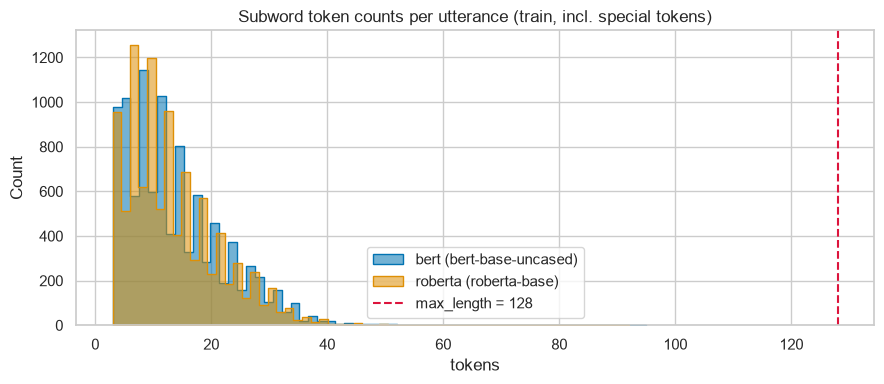

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for i, (key, lens) in enumerate(tok_lengths.items()):
    sns.histplot(lens, bins=60, ax=ax, label=f"{key} ({utils.MODELS[key]})",
                 color=PALETTE[i], alpha=0.55, element="step")
ax.axvline(utils.MAX_LENGTH, color="crimson", ls="--", label=f"max_length = {utils.MAX_LENGTH}")
ax.set_title("Subword token counts per utterance (train, incl. special tokens)")
ax.set_xlabel("tokens")
ax.legend()
fig.tight_layout()
fig.savefig(utils.FIGURES / "token_length_distribution.png", dpi=150)
plt.show()

In [11]:
for key, lens in tok_lengths.items():
    truncated = (lens > utils.MAX_LENGTH).sum()
    print(f"{key:8s} max_length={utils.MAX_LENGTH} truncates {truncated} / {len(lens)} train utterances")

print(
    "\nmax_length = 128 is a safe ceiling: it truncates essentially nothing.\n"
    "Padding is dynamic (DataCollatorWithPadding), so each batch pads only to\n"
    "its own longest member (~median 12 tokens) rather than to 128 — the\n"
    "ceiling costs almost no compute while removing truncation as a variable."
)

bert     max_length=128 truncates 0 / 9989 train utterances
roberta  max_length=128 truncates 0 / 9989 train utterances

max_length = 128 is a safe ceiling: it truncates essentially nothing.
Padding is dynamic (DataCollatorWithPadding), so each batch pads only to
its own longest member (~median 12 tokens) rather than to 128 — the
ceiling costs almost no compute while removing truncation as a variable.


## 5. Class weights (step 4c)

**Why weighting and not resampling.** Three options were on the table:

1. *Oversample rare classes* — duplicates the ~270 fear/disgust utterances
   many times over. With only ~270 distinct examples, a 17× duplication
   invites the model to memorize them verbatim rather than generalize.
2. *Undersample neutral* — throws away thousands of real utterances from a
   corpus that is already small (~10k).
3. *Class-weighted loss* — leaves the data exactly as shipped and rescales
   each class's contribution to the gradient.

We take option 3. It changes no data, adds no runtime, keeps the official
splits comparable to published baselines, and is the standard low-risk
choice under a time constraint. Its cost is a known bias toward
over-predicting rare classes (recall up, precision down) — notebook 04
checks whether that actually happened.

Weights use the standard inverse-frequency form,
`w_c = n_samples / (n_classes * count_c)`, computed on **train only** —
using dev or test counts would leak information about the evaluation sets.

In [12]:
counts_by_id = train["label"].value_counts().sort_index()
n_samples = len(train)
weights = n_samples / (utils.NUM_LABELS * counts_by_id)

weight_table = pd.DataFrame(
    {
        "label_id": counts_by_id.index,
        "emotion": [utils.ID2LABEL[i] for i in counts_by_id.index],
        "train_count": counts_by_id.values,
        "train_pct": (100 * counts_by_id.values / n_samples).round(2),
        "weight": weights.values.round(4),
    }
)
weight_table

,label_id,emotion,train_count,train_pct,weight
0,0,neutral,4710,47.15,0.3030
1,1,joy,1743,17.45,0.8187
2,2,surprise,1205,12.06,1.1842
3,3,anger,1109,11.10,1.2867
4,4,sadness,683,6.84,2.0893
5,5,disgust,271,2.71,5.2657
6,6,fear,268,2.68,5.3246


In [13]:
# sklearn's balanced weighting is the same formula — cross-check we agree.
from sklearn.utils.class_weight import compute_class_weight  # noqa: E402

sk = compute_class_weight("balanced", classes=np.arange(utils.NUM_LABELS), y=train["label"])
assert np.allclose(sk, weights.values), "weight formula disagrees with sklearn"
print("matches sklearn's 'balanced' weights")

payload = {
    "formula": "n_samples / (n_classes * count_c), computed on the train split only",
    "n_samples": int(n_samples),
    "n_classes": int(utils.NUM_LABELS),
    "weights": {utils.ID2LABEL[int(i)]: float(w) for i, w in zip(counts_by_id.index, weights.values)},
    "counts": {utils.ID2LABEL[int(i)]: int(c) for i, c in zip(counts_by_id.index, counts_by_id.values)},
}
with open(utils.class_weights_path(), "w", encoding="utf-8") as fh:
    json.dump(payload, fh, indent=2)

weight_table.to_csv(utils.RESULTS / "class_weights.csv", index=False)
print(f"wrote {utils.class_weights_path().name}")

# Confirm utils can read them back in label-id order — notebook 03 depends on this.
loaded = utils.load_class_weights()
assert np.allclose(loaded, weights.values), "round-trip mismatch"
print("round-trip OK:", np.round(loaded, 3))

matches sklearn's 'balanced' weights
wrote class_weights.json
round-trip OK: [0.303 0.819 1.184 1.287 2.089 5.266 5.325]


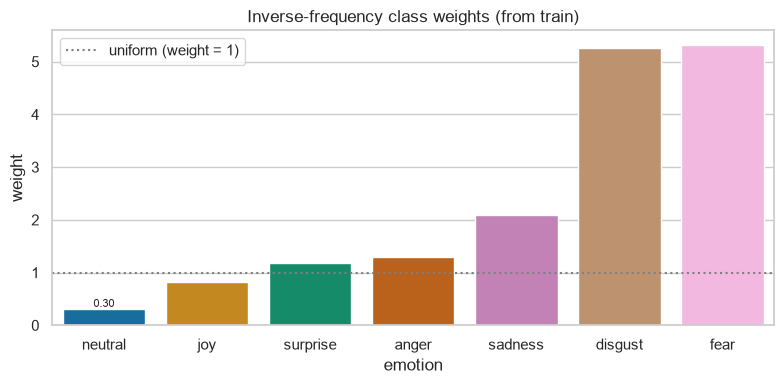

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=weight_table, x="emotion", y="weight", ax=ax, palette="colorblind",
            hue="emotion", legend=False)
ax.set_title("Inverse-frequency class weights (from train)")
ax.axhline(1.0, color="gray", ls=":", label="uniform (weight = 1)")
ax.bar_label(ax.containers[0], fmt="%.2f", fontsize=8)
ax.legend()
fig.tight_layout()
fig.savefig(utils.FIGURES / "class_weights.png", dpi=150)
plt.show()

## Summary

- Imbalance confirmed: neutral ~47% of train, fear/disgust <3% — a ~17.6×
  ratio. Majority-class baseline is ~47% accuracy, so **weighted F1 is the
  primary metric** and macro F1 guards the rare classes.
- Utterances are very short (median 6 words / ~12 subword tokens).
- Tokenizers differ as expected: BERT WordPiece lowercases and emits `##`
  continuations; RoBERTa byte-level BPE preserves case and marks leading
  spaces with `Ġ`. RoBERTa's case-sensitivity may help on shouted utterances.
- `max_length = 128` truncates essentially nothing; dynamic padding keeps the
  generous ceiling cheap.
- Class weights computed on train only and saved to
  `results/class_weights.json` for notebook 03's weighted loss.

Next: `03_finetuning_and_tuning.py`.